In [1]:
def import_module_demo():
  try:
    import geometry_2d.line
    print("Module imported successfully")
  except ModuleNotFoundError:
    print("Module not found. Please install geometry 2d package.")


In [2]:
import_module_demo()

Module imported successfully


In [3]:
import numpy as np

In [4]:
def solve_linear_system():
  A = [[1, -3, 3], [2, 3, -1], [4, -3, -1]]
  B= [-4, 15, 19]
  x, y, z = np.linalg.solve(A, B)
  X = [x, y, z]
  print(f"x = {round(x, 2)}")
  print(f"y = {round(y, 2)}")
  print(f"z = {round(z, 2)}")

  eq1 = x - 3*y + 3*z
  eq2 = 2*x + 3*y -z
  eq3 = 4*x - 3*y -z

  print("\nVerification:")
  print(f"Equation 1: {round(x, 2)} - {round(3*y, 2)} - {round(3*z, 2)} = {round(eq1, 2)}")
  print(f"Equation 2: {round(2*x, 2)} + {round(3*y, 2)} - {round(z, 2)} = {round(eq2, 2)}")
  print(f"Equation 1: {round(4*x, 2)} - {round(3*y, 2)} - {round(z, 2)} = {round(eq3, 2)}")

In [5]:
solve_linear_system()

x = 5.0
y = 1.0
z = -2.0

Verification:
Equation 1: 5.0 - 3.0 - -6.0 = -4.0
Equation 2: 10.0 + 3.0 - -2.0 = 15.0
Equation 1: 20.0 - 3.0 - -2.0 = 19.0


In [6]:
import matplotlib.pyplot as plt

In [7]:
def plot_quadratic():
  x = np.linspace(-10, 10, 1000)
  y = lambda x: x**2 + 2*x

  plt.plot(x, y(x), label="y = x^2 + 2x")
  plt.legend()
  plt.title("Plot of y = x^2 + 2x")
  plt.xlabel("x values")
  plt.ylabel("y values")
  plt.show()

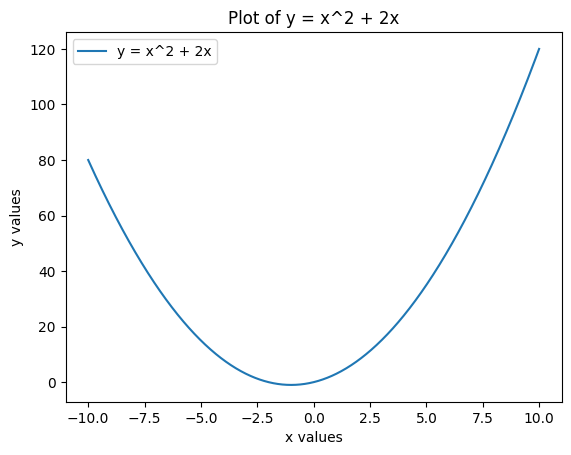

In [8]:
plot_quadratic()

In [9]:
def analyze_text_file(filename: str):
  with open (filename, "r") as f:
    data = f.read()

  # total number of words
  words = data.split()
  word_count = len(words)

  # longest word
  word_lens = {}
  cleaned_data = ""
  for ch in data:
    if ch not in ".!,?":
      cleaned_data+=ch

  words_cleaned = cleaned_data.split()
  for word in words_cleaned:
    word_lens[word] = len(word)

  longest_word_len = max(word_lens.values())
  for word, word_len in word_lens.items():
    if word_len == longest_word_len:
      longest_word = word

  # total number of sentences
  sentences = {}
  sentence_count = 0
  curr = ""
  for ch in data:
    curr+=ch
    if ch in ".!?":
      sentence_count +=1
      sentences[curr] = len(curr)
      curr = ""

  # longest sentence by character
  longest_sen_len = max(sentences.values())
  for sentence, sentence_len in sentences.items():
    if sentence_len == longest_sen_len:
      longest_sentence = sentence

  lower_words = []
  for word in words:
    lower_words.append(word.lower())

  # word frequency
  word_frequency = {}
  for word in lower_words:
    if word in word_frequency:
      word_frequency[word] +=  1
    else:
      word_frequency[word] = 1

  # vocabulary
  vocabulary = set(lower_words)
  return {
      "word_count": word_count,
      "sentence_count": sentence_count,
      "longest_word": longest_word,
      "longest_sentence": longest_sentence,
      "word_frequency": word_frequency,
      "vocabulary": vocabulary
  }


In [10]:
with open("sample.txt", 'w') as f:
  f.write("Hello world! This is a sample text. Python is great. Hello again.")

In [11]:
analyze_text_file("sample.txt")

{'word_count': 12,
 'sentence_count': 4,
 'longest_word': 'Python',
 'longest_sentence': ' This is a sample text.',
 'word_frequency': {'hello': 2,
  'world!': 1,
  'this': 1,
  'is': 2,
  'a': 1,
  'sample': 1,
  'text.': 1,
  'python': 1,
  'great.': 1,
  'again.': 1},
 'vocabulary': {'a',
  'again.',
  'great.',
  'hello',
  'is',
  'python',
  'sample',
  'text.',
  'this',
  'world!'}}

In [12]:
import json

In [13]:
def subject_analysis(filename: str):
  with open (filename, 'r') as f:
    data = json.load(f)

  student_marks = {}
  for student in data["students"]:
    marks = []
    for subject in student["subjects"]:
      marks.append(student["subjects"][subject])

    student_marks[student["name"]] = marks

  total_marks = {}
  for student, marks in student_marks.items():
    total_marks[student] = sum(marks)

  # overall topper
  toppers = []
  max_total = max(total_marks.values())
  for student, total in total_marks.items():
    if total == max_total:
      toppers.append({"name": student, "total": total})

  # subjects toppers
  subject_toppers = {}
  temp = []
  for student in data["students"]:
    for subject in student["subjects"]:
      temp.append(subject)

  all_subjects = set(temp)

  for subject in all_subjects:
    max_mark = -1
    for student in data["students"]:
      if subject in student["subjects"]:
        if(max_mark < student["subjects"][subject]):
          max_mark = student["subjects"][subject]

    sub_toppers = []

    for student in data["students"]:
      if subject in student["subjects"]:
        marks = student["subjects"][subject]
        if marks == max_mark:
          sub_toppers.append({"name": student["name"], "marks": marks})

    subject_toppers[subject] = sub_toppers

  return {
    "overall_topper": toppers,
    "subject_toppers": subject_toppers
}


In [14]:
data = {
    "students": [
        {
            "name": "Arjun",
            "subjects": {
                "Math": 85,
                "Science": 90,
                "English": 88
            }
        },
        {
            "name": "Priya",
            "subjects": {
                "Math": 95,
                "Science": 92,
                "English": 91
            }
        }
    ]
}

with open("students_subjects.json", "w") as f:
    json.dump(data, f, indent=4)

In [15]:
subject_analysis("students_subjects.json")

{'overall_topper': [{'name': 'Priya', 'total': 278}],
 'subject_toppers': {'Math': [{'name': 'Priya', 'marks': 95}],
  'English': [{'name': 'Priya', 'marks': 91}],
  'Science': [{'name': 'Priya', 'marks': 92}]}}

In [16]:
!mkdir geometry_2d

mkdir: cannot create directory ‘geometry_2d’: File exists


In [17]:
%%writefile geometry_2d/line.py
class Line:
  def __init__(self, x1, y1, x2, y2):
    self.x1 = x1
    self.y1 = y1
    self.x2 = x2
    self.y2 = y2

  def slope(self):
    if self.x2-self.x1 == 0:
      return None
    return (self.y2-self.y1)/(self.x2-self.x1)

  def length(self):
    return ((self.x2-self.x1)**2 + (self.y2-self.y1)**2)**(0.5)

  def passes_through_origin(self):
    if(self.x2*self.y1 - self.x1*self.y2 == 0):
      return True
    else:
      return False

Overwriting geometry_2d/line.py


In [18]:
%%writefile geometry_2d/circle.py
class Circle:
  def __init__(self, cx, cy, radius):
    self.cx = cx
    self.cy = cy
    self.radius = radius

  def area(self):
    return 3.14*self.radius*self.radius

  def circumference(self):
    return 2*3.14*self.radius

  def contains_point(self, x, y):
    d = ((x - self.cx)**2 + (y - self.cy)**2)**(0.5)
    if(d <= self.radius):
      return True
    else:
      return False

Overwriting geometry_2d/circle.py


In [19]:
def circle_line_analysis(circle, line):
  A = line.y2 - line.y1
  B = line.x1 - line.x2
  C = line.x2*line.y1 - line.x1*line.y2

  d = abs(A*circle.cx + B*circle.cy + C)/(((A)**2 + (B)**2)**(0.5))

In [20]:
from geometry_2d.line import Line
from geometry_2d.circle import Circle

line = Line(0, 0, 3, 4)
print(f"Slope: {line.slope()}")
print(f"Length: {line.length()}")
print(f"Passes through origin: {line.passes_through_origin()}")

circle = Circle(0, 0, 5)
print(f"Area: {circle.area()}")
print(f"Contains point (3,4): {circle.contains_point(3,4)}")

Slope: 1.3333333333333333
Length: 5.0
Passes through origin: True
Area: 78.5
Contains point (3,4): True
